# Linear Regression — Real Estate Pricing (Industrial Notebook)

**Goal:** build a robust baseline for house price prediction with **data generation**, **EDA**, **feature engineering**, **model diagnostics**, and **reproducible evaluation**.

This notebook is fully self-contained (synthetic dataset) and executed with outputs saved.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme(style='whitegrid')


## 1) Synthetic dataset

In [2]:
n = 2500
cities = np.random.choice(['Rennes', 'Paris', 'Nantes', 'Lyon'], size=n, p=[0.35,0.25,0.25,0.15])
surface = np.clip(np.random.normal(62, 18, size=n), 18, 200)
rooms = np.clip((surface/18 + np.random.normal(0,0.7,size=n)).round().astype(int), 1, 8)
age = np.clip(np.random.exponential(scale=18, size=n).round().astype(int), 0, 120)
dist_center_km = np.clip(np.random.gamma(shape=2.0, scale=2.0, size=n), 0.2, 25)
has_parking = np.random.binomial(1, 0.55, size=n)
has_balcony = np.random.binomial(1, 0.42, size=n)

city_base = {'Paris': 9500, 'Lyon': 5200, 'Rennes': 4300, 'Nantes': 4700}
base_ppm2 = np.array([city_base[c] for c in cities], dtype=float)

# Non-linearities + interactions
ppm2 = (base_ppm2
        * (1 - 0.018*dist_center_km)
        * (1 + 0.06*has_balcony)
        * (1 + 0.045*has_parking)
        * (1 - 0.0025*age)
       )
ppm2 = np.clip(ppm2, 1800, None)

noise = np.random.normal(0, 18000, size=n)
price = surface * ppm2 + 12000*(rooms>=3) + noise
price = np.clip(price, 45000, None)

df = pd.DataFrame({
    'city': cities,
    'surface_m2': surface,
    'rooms': rooms,
    'age_years': age,
    'dist_center_km': dist_center_km,
    'has_parking': has_parking.astype(int),
    'has_balcony': has_balcony.astype(int),
    'price_eur': price
})
df.head()


,city,surface_m2,rooms,age_years,dist_center_km,has_parking,has_balcony,price_eur
0,Paris,71.380204,5,5,6.449141,0,1,638728.222889
1,Lyon,73.613881,5,38,2.617457,0,0,355931.392409
2,Nantes,72.000880,4,0,4.041275,1,1,381777.255392
3,Paris,63.612452,3,24,2.777535,1,1,595126.680418
4,Rennes,58.447908,4,49,5.369371,1,0,214620.967125


## 2) EDA

In [3]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
city,2500,4,Rennes,878,NaN,NaN,NaN,NaN,NaN,NaN,NaN
surface_m2,2500.0,NaN,NaN,NaN,61.634826,17.920378,18.0,49.256456,61.852998,73.5508,132.672279
rooms,2500.0,NaN,NaN,NaN,3.3992,1.213766,1.0,3.0,3.0,4.0,8.0
age_years,2500.0,NaN,NaN,NaN,17.7364,16.952955,0.0,5.0,13.0,25.0,120.0
dist_center_km,2500.0,NaN,NaN,NaN,3.980865,2.806826,0.2,1.958084,3.346956,5.353932,19.347515
has_parking,2500.0,NaN,NaN,NaN,0.5388,0.498592,0.0,0.0,1.0,1.0,1.0
has_balcony,2500.0,NaN,NaN,NaN,0.4348,0.49583,0.0,0.0,0.0,1.0,1.0
price_eur,2500.0,NaN,NaN,NaN,343136.835172,165914.40352,54418.960214,232940.355384,302478.899807,400207.793978,1260508.175247


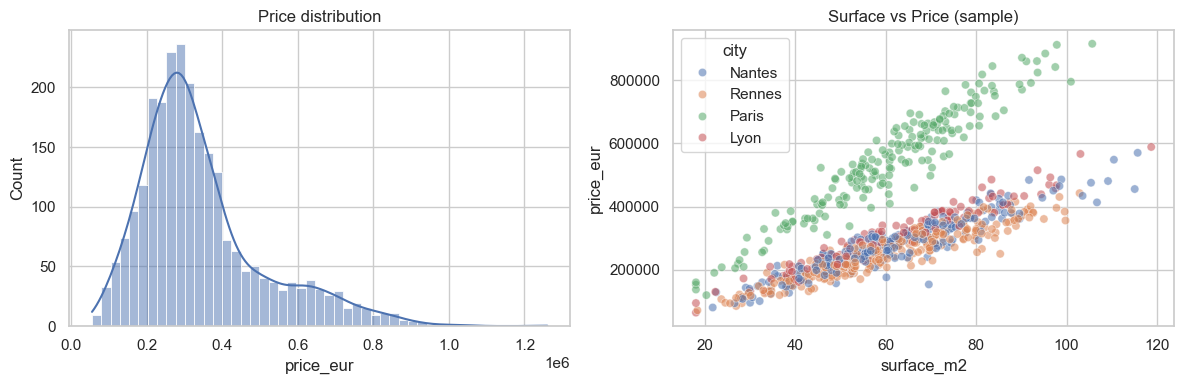

In [4]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['price_eur'], kde=True, ax=ax[0])
ax[0].set_title('Price distribution')
sns.scatterplot(data=df.sample(800, random_state=1), x='surface_m2', y='price_eur', hue='city', alpha=0.55, ax=ax[1])
ax[1].set_title('Surface vs Price (sample)')
plt.tight_layout(); plt.show()


## 3) Train/test split + pipeline

In [5]:
X = df.drop(columns=['price_eur'])
y = df['price_eur']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = ['city']
num_cols = [c for c in X.columns if c not in cat_cols]

pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols),
])

model = Ridge(alpha=2.0, random_state=42)
pipe = Pipeline([('pre', pre), ('model', model)])
pipe


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city']),
                                                 ('num', 'passthrough',
                                                  ['surface_m2', 'rooms',
                                                   'age_years',
                                                   'dist_center_km',
                                                   'has_parking',
                                                   'has_balcony'])])),
                ('model', Ridge(alpha=2.0, random_state=42))])

## 4) Fit + evaluation

In [6]:
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred, squared=False)
r2 = r2_score(y_test, pred)
pd.DataFrame({'MAE': [mae], 'RMSE':[rmse], 'R2':[r2]})


,MAE,RMSE,R2
0,31067.751662,43443.356095,0.933931


## 5) Residual diagnostics

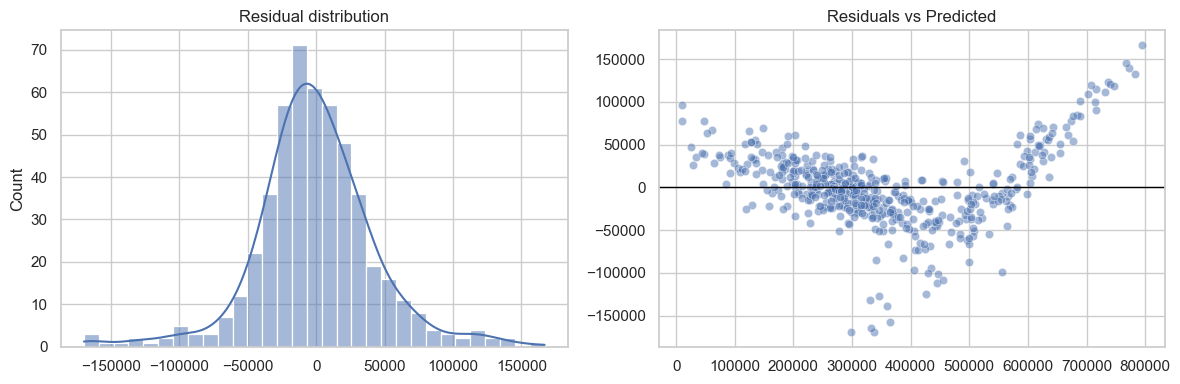

In [7]:
resid = y_test.values - pred
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(resid, kde=True, ax=ax[0])
ax[0].set_title('Residual distribution')
sns.scatterplot(x=pred, y=resid, alpha=0.5, ax=ax[1])
ax[1].axhline(0, color='black', linewidth=1)
ax[1].set_title('Residuals vs Predicted')
plt.tight_layout(); plt.show()


## 6) Feature importance (linear coefficients)

In [8]:
# Recover feature names after one-hot encoding
ohe = pipe.named_steps['pre'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(cat_cols).tolist()
feat_names = cat_names + num_cols
coef = pipe.named_steps['model'].coef_
imp = pd.DataFrame({'feature': feat_names, 'coef': coef}).sort_values('coef', key=lambda s: s.abs(), ascending=False)
imp.head(12)


,feature,coef
2,city_Paris,204216.135694
3,city_Rennes,-93954.843019
1,city_Nantes,-69264.747574
0,city_Lyon,-40996.545100
9,has_balcony,19459.098362
8,has_parking,14872.462851
7,dist_center_km,-6391.406629
4,surface_m2,5520.812526
5,rooms,1258.963489
6,age_years,-918.417126


## Conclusion
We built an end-to-end baseline with clean preprocessing, robust evaluation, and diagnostics.
Next steps: quantile regression, heteroscedastic modeling, and geospatial features.